In [1]:
from utils import *
NOTEBOOK_ID = '06'

# output files for circos plot

In [2]:
data_df = pd.read_csv(f'{ANALYSIS_DIR}/experimental_data_fitted.csv')
x = data_df.groupby(['tax_id'])['tile_ID'].nunique()
x.to_csv(f'{ANALYSIS_DIR}/tax_counts.csv')

activator_df = data_df.query('is_activator == True')
activator_df.groupby('tax_id')['tile_ID'].nunique().to_csv(f'{ANALYSIS_DIR}/activator_counts.csv')
y = (activator_df.groupby('tax_id')['tile_ID'].nunique() / data_df.groupby(['tax_id'])['tile_ID'].nunique()).fillna(0.0)
y.to_csv(f'{ANALYSIS_DIR}/normalized_activator_counts.csv')
tmp_df = x.reset_index().rename(columns={'tile_ID':'count'}).merge(y.reset_index().rename(columns={'tile_ID':'norm_activator_count'}))
    
tmp_df['family'] = tmp_df['tax_id'].apply(lambda x: get_taxonomic_family(x))
tmp_df.to_csv(f'{ANALYSIS_DIR}/tax_counts_merged.csv',index=False)

family_mapper = dict(zip(tmp_df['tax_id'].astype(str),tmp_df['family']))
tree = Tree(f"{METADATA_DIR}/ncbi_virus_tree.nwk", format=1)
for leaf in tree:
    if leaf.name in family_mapper:
        leaf.name = family_mapper[leaf.name]
tree.write(format=1, outfile=f"{METADATA_DIR}/ncbi_virus_tree_family.nwk")

# heatmaps

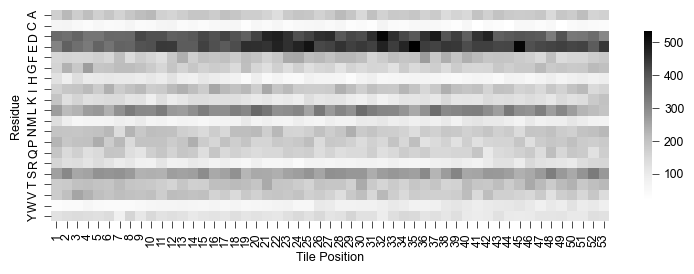

In [3]:
background_aa_df = data_df['tile'].apply(lambda x: pd.Series(list(x))).reset_index().melt(id_vars='index',var_name='position',value_name='AA')
background_attributes_df = background_aa_df.copy()
background_attributes_df['AA_attributes'] = background_attributes_df['AA'].map(AA_DICT)
background_aa_df = background_aa_df.groupby(['position','AA'])['index'].count().reset_index().pivot(index='AA',columns='position',values='index').fillna(0.0)
background_attributes_df = background_attributes_df.explode('AA_attributes').groupby(['position','AA_attributes'])['index'].count().reset_index().pivot(index='AA_attributes',columns='position',values='index').fillna(0.0)

activator_df = data_df.query('is_activator == True')
activator_aa_df = activator_df['tile'].apply(lambda x: pd.Series(list(x))).reset_index().melt(id_vars='index',var_name='position',value_name='AA')
activator_attributes_df = activator_aa_df.copy()
activator_attributes_df['AA_attributes'] = activator_attributes_df['AA'].map(AA_DICT)
activator_aa_df = activator_aa_df.groupby(['position','AA'])['index'].count().reset_index().pivot(index='AA',columns='position',values='index').fillna(0.0)
activator_aa_df = activator_aa_df / background_aa_df
activator_attributes_df = activator_attributes_df.explode('AA_attributes').groupby(['position','AA_attributes'])['index'].count().reset_index().pivot(index='AA_attributes',columns='position',values='index').fillna(0.0)
activator_attributes_df = activator_attributes_df / background_attributes_df

plt.figure(figsize=(9,2.75))
g = sns.heatmap(background_aa_df,
            cmap=sns.color_palette("Greys", as_cmap=True), 
            xticklabels=True,yticklabels=True,cbar_kws=dict(shrink=0.8))
new_labels = [str(int(label + 1)) for label in g.get_xticks()]
g.set(xlabel='Tile Position',ylabel='Residue',xticklabels=new_labels)
if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-library_heatmap_aa_overall.svg',**FIG_PARAMS)

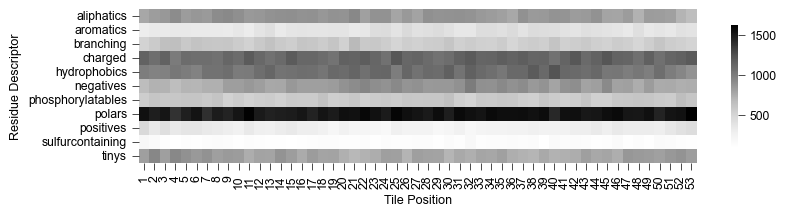

In [4]:
plt.figure(figsize=(9,2))
g = sns.heatmap(background_attributes_df,
            cmap=sns.color_palette("Greys", as_cmap=True), 
            xticklabels=True,yticklabels=True,cbar_kws=dict(shrink=0.8))
new_labels = [str(int(label + 1)) for label in g.get_xticks()]
g.set(xlabel='Tile Position',ylabel='Residue Descriptor',xticklabels=new_labels)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-library_heatmap_attributes_overall.svg',**FIG_PARAMS)

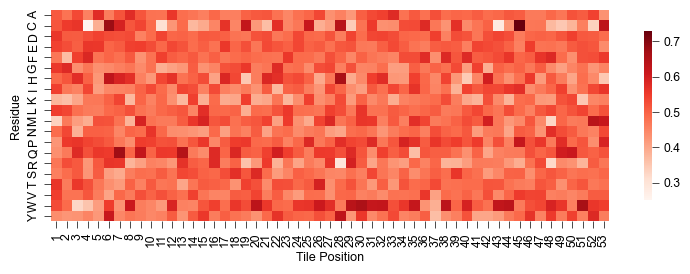

In [5]:
plt.figure(figsize=(9,2.75))
g = sns.heatmap(activator_aa_df,
            cmap=sns.color_palette("Reds", as_cmap=True), 
            xticklabels=True,yticklabels=True,cbar_kws=dict(shrink=0.8))
new_labels = [str(int(label + 1)) for label in g.get_xticks()]
g.set(xlabel='Tile Position',ylabel='Residue',xticklabels=new_labels)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-library_heatmap_aa_activators.svg',**FIG_PARAMS)

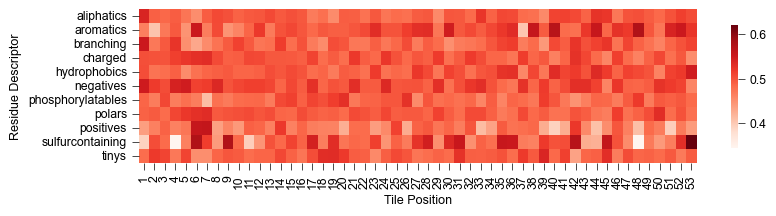

In [6]:
plt.figure(figsize=(9,2.))
g = sns.heatmap(activator_attributes_df,
            cmap=sns.color_palette("Reds", as_cmap=True), 
            xticklabels=True,yticklabels=True,cbar_kws=dict(shrink=0.8))

new_labels = [str(int(label + 1)) for label in g.get_xticks()]
g.set(xlabel='Tile Position',ylabel='Residue Descriptor',xticklabels=new_labels)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-library_heatmap_attributes_activators.svg',**FIG_PARAMS)